STEP 1.1 – GOOGLE DRIVE MOUNT

This step is used to mount Google Drive in Google Colab. Mounting Google Drive allows direct access to the dataset, trained models, generated results, and project files. It also ensures that the work is automatically saved and can be accessed even if the Colab session disconnects.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STEP 1.2 – CREATE PROJECT FOLDER STRUCTURE

This step creates a well-organized project directory in Google Drive. Keeping datasets, models, results, notebooks, and reports in separate folders improves project management and makes it easier to upload the project to GitHub and prepare the final report.

In [ ]:
import os

project_path = "/content/drive/MyDrive/Malaria_Project"

folders = [
    "results",
    "models",
    "report",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


STEP 1.3 – VERIFY DATASET LOCATION

In [2]:
dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"

print("Dataset Path:", dataset_path)

Dataset Path: /content/drive/MyDrive/Malaria_Project/datasets/cell_images


STEP 1.4 – VERIFY DATASET FOLDER STRUCTURE

In [3]:
import os

classes = os.listdir(dataset_path)

print("Classes Found:")
print(classes)

Classes Found:
['Uninfected', 'Parasitized']


STEP 1.3 – IMPORT REQUIRED LIBRARIES

Deep learning projects require multiple Python libraries for data manipulation, visualization, model development, evaluation, and file management. Importing all libraries at the beginning ensures that the environment is ready for the remaining project stages.

In [4]:
# =====================================================
# STEP 1.3 – IMPORT REQUIRED LIBRARIES
# =====================================================

import os
import random
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

warnings.filterwarnings("ignore")

print("="*60)
print(" Libraries imported successfully.")
print("="*60)

 Libraries imported successfully.


In [5]:
# =====================================================
# STEP 1.5 – VERIFY DATASET LOCATION
# =====================================================

import os

DATASET_PATH = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("Dataset Path :", DATASET_PATH)
print("Folder Exists:", os.path.exists(DATASET_PATH))

DATASET VERIFICATION
Dataset Path : /content/drive/MyDrive/Malaria_Project/datasets/cell_images
Folder Exists: True


In [6]:
# =====================================================
# STEP 1.4 – CHECK GPU
# =====================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print(" Device Information")
print("="*60)

print("Using Device :", device)

if torch.cuda.is_available():
    print("GPU Name :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

 Device Information
Using Device : cpu
Running on CPU


In [7]:
# =====================================================
# STEP 1.6 – VERIFY DATASET STRUCTURE
# =====================================================

import os

classes = sorted(os.listdir(DATASET_PATH))

print("=" * 60)
print("CLASS FOLDERS FOUND")
print("=" * 60)

for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

print("\nTotal Classes:", len(classes))

CLASS FOLDERS FOUND
1. Parasitized
2. Uninfected

Total Classes: 2


PHASE 2 – EXPLORATORY DATA ANALYSIS (EDA)

STEP 2.1 – IMPORT LIBRARIES FOR EDA

In [8]:
# =====================================================
# STEP 2.1 – IMPORT LIBRARIES FOR EDA
# =====================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

print("=" * 60)
print("EDA Libraries Imported Successfully")
print("=" * 60)

EDA Libraries Imported Successfully


STEP 2.2 – DATASET INFORMATION

In [9]:
# =====================================================
# STEP 2.2 – DATASET INFORMATION
# =====================================================

dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"

classes = sorted(os.listdir(dataset_path))

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

total_images = 0

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    class_counts[cls] = count
    total_images += count

    print(f"{cls:<15}: {count}")

print("-" * 60)
print(f"Total Classes : {len(classes)}")
print(f"Total Images  : {total_images}")

DATASET INFORMATION
Parasitized    : 13779
Uninfected     : 13778
------------------------------------------------------------
Total Classes : 2
Total Images  : 27557


In [10]:
# =====================================================
# CREATE BALANCED DATASET SUBSET
# =====================================================

import os
import random
import shutil

random.seed(42)

original_dataset = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"
subset_dataset = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

classes = ["Parasitized", "Uninfected"]

IMAGES_PER_CLASS = 6500

for cls in classes:

    source = os.path.join(original_dataset, cls)
    destination = os.path.join(subset_dataset, cls)

    os.makedirs(destination, exist_ok=True)

    images = [
        img for img in os.listdir(source)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    selected = random.sample(images, IMAGES_PER_CLASS)

    print(f"\nCopying {cls} images...")

    for img in selected:
        shutil.copy2(
            os.path.join(source, img),
            os.path.join(destination, img)
        )

    print(f"{cls}: {len(selected)} images copied.")

print("\n")
print("="*60)
print("Balanced subset created successfully.")
print("="*60)


Copying Parasitized images...
Parasitized: 6500 images copied.

Copying Uninfected images...
Uninfected: 6500 images copied.


Balanced subset created successfully.


In [11]:
# =====================================================
# VERIFY SUBSET
# =====================================================

subset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

for cls in sorted(os.listdir(subset_path)):

    class_path = os.path.join(subset_path, cls)

    count = len(os.listdir(class_path))

    print(f"{cls:<15}: {count}")

print("\nTotal Images:", sum(
    len(os.listdir(os.path.join(subset_path, c)))
    for c in os.listdir(subset_path)
))

Parasitized    : 6500
Uninfected     : 6500

Total Images: 13000


In [12]:
dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

STEP 2.3 – VISUALIZE CLASS DISTRIBUTION

In [ ]:
# =====================================================
# CREATE FIGURES FOLDER
# =====================================================

import os

FIGURE_PATH = "/content/drive/MyDrive/Malaria_Project/figures"

os.makedirs(FIGURE_PATH, exist_ok=True)

print("✅ Figures folder is ready.")

✅ Figures folder is ready.


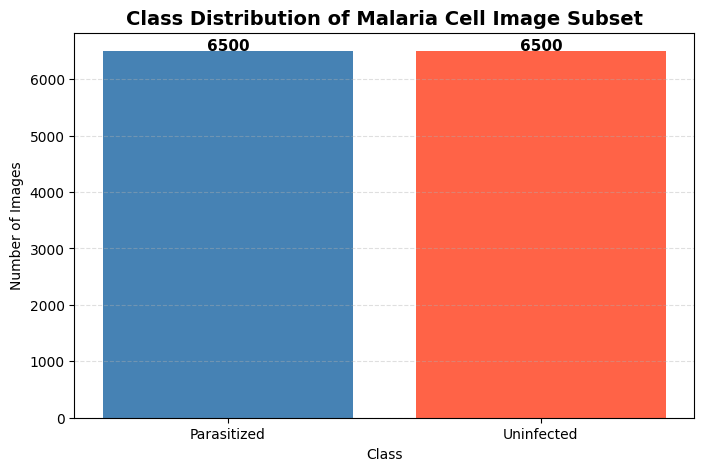


Figure Saved Successfully!


In [14]:
# =====================================================
# STEP 2.3 – CLASS DISTRIBUTION
# =====================================================

import matplotlib.pyplot as plt
import os

# Create figures folder if it doesn't exist
os.makedirs("/content/drive/MyDrive/Malaria_Project/figures", exist_ok=True)

class_names = list(class_counts.keys())
image_counts = list(class_counts.values())

plt.figure(figsize=(8,5))

bars = plt.bar(
    class_names,
    image_counts,
    color=["steelblue","tomato"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+20,
        f"{height}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Class Distribution of Malaria Cell Image Subset",fontsize=14,fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y",linestyle="--",alpha=0.4)

save_path="/content/drive/MyDrive/Malaria_Project/figures/class_distribution.png"

plt.savefig(save_path,dpi=300,bbox_inches="tight")

plt.show()

print("\nFigure Saved Successfully!")

STEP 2.4 – DISPLAY RANDOM SAMPLE IMAGES

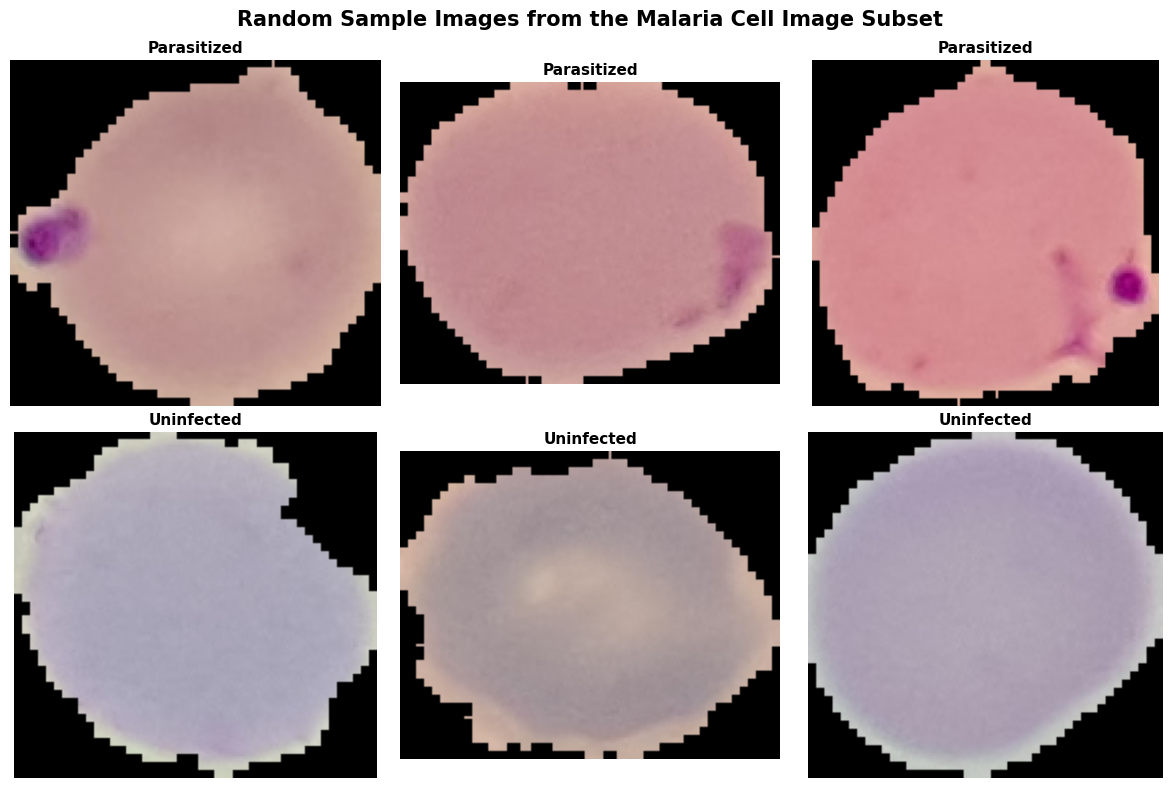

Figure saved successfully!
/content/drive/MyDrive/Malaria_Project/figures/sample_images.png


In [15]:
# =====================================================
# STEP 2.4 – DISPLAY RANDOM SAMPLE IMAGES
# =====================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

classes = ["Parasitized", "Uninfected"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    image_list = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    selected_images = random.sample(image_list, 3)

    for col, image_name in enumerate(selected_images):

        img_path = os.path.join(class_path, image_name)

        img = Image.open(img_path)

        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=11, fontweight="bold")
        axes[row, col].axis("off")

plt.suptitle(
    "Random Sample Images from the Malaria Cell Image Subset",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

save_path = "/content/drive/MyDrive/Malaria_Project/figures/sample_images.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved successfully!")
print(save_path)

STEP 2.5 – IMAGE RESOLUTION ANALYSIS

Image resolution analysis is an important part of Exploratory Data Analysis (EDA). This step examines the width and height of all images in the dataset to understand their original dimensions. Since deep learning models require images of a fixed size, this analysis justifies resizing all images to 224 × 224 pixels during preprocessing. It also helps identify any irregular image dimensions.

In [16]:
# =====================================================
# STEP 2.5 – IMAGE RESOLUTION ANALYSIS
# =====================================================

import os
import numpy as np
from PIL import Image

dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

widths = []
heights = []

for cls in ["Parasitized", "Uninfected"]:

    class_path = os.path.join(dataset_path, cls)

    for image_name in os.listdir(class_path):

        if image_name.lower().endswith((".png", ".jpg", ".jpeg")):

            img_path = os.path.join(class_path, image_name)

            try:
                img = Image.open(img_path)
                w, h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

print("=" * 60)
print("IMAGE RESOLUTION ANALYSIS")
print("=" * 60)

print(f"Total Images        : {len(widths)}")
print(f"Minimum Width       : {min(widths)}")
print(f"Maximum Width       : {max(widths)}")
print(f"Average Width       : {np.mean(widths):.2f}")

print()

print(f"Minimum Height      : {min(heights)}")
print(f"Maximum Height      : {max(heights)}")
print(f"Average Height      : {np.mean(heights):.2f}")

IMAGE RESOLUTION ANALYSIS
Total Images        : 13000
Minimum Width       : 46
Maximum Width       : 364
Average Width       : 132.33

Minimum Height      : 40
Maximum Height      : 385
Average Height      : 132.94


STEP 2.6 – IMAGE SIZE DISTRIBUTION

This step visualizes the distribution of image widths and heights in the dataset. It helps identify the variation in image dimensions and provides evidence for the resizing strategy adopted during preprocessing.

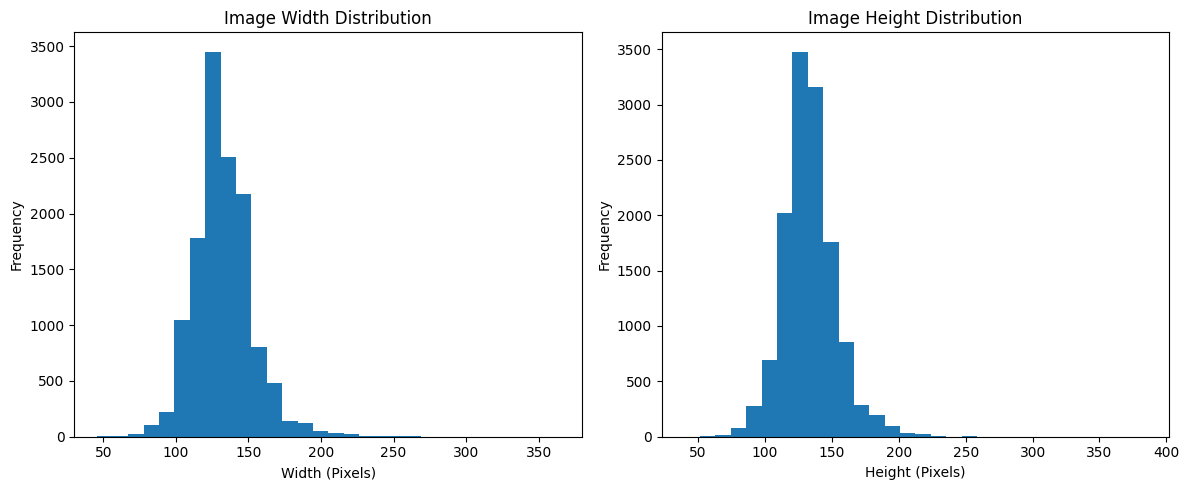

Figure saved successfully!
/content/drive/MyDrive/Malaria_Project/figures/image_resolution_distribution.png


In [17]:
# =====================================================
# STEP 2.6 – IMAGE SIZE DISTRIBUTION
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width (Pixels)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height (Pixels)")
plt.ylabel("Frequency")

plt.tight_layout()

save_path = "/content/drive/MyDrive/Malaria_Project/figures/image_resolution_distribution.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved successfully!")
print(save_path)

PHASE 3 – DATA PREPROCESSING

STEP 3.1 – CREATE TRAIN, VALIDATION, AND TEST SPLIT (80/10/10)

Before training the deep learning models, the dataset must be divided into three subsets:

Training Set (80%) – Used to train the CNN and MobileNetV2 models.
Validation Set (10%) – Used during training to monitor model performance and tune hyperparameters.
Test Set (10%) – Used only after training to evaluate the final model on unseen data.

Using separate datasets helps prevent overfitting and provides an unbiased estimate of model performance.

In [18]:
# =====================================================
# STEP 3.1 – CREATE TRAIN / VALIDATION / TEST SPLIT
# =====================================================

import os
import shutil
import random

random.seed(42)

# Original subset path
dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

# Destination path
split_path = "/content/drive/MyDrive/Malaria_Project/datasets/split_dataset"

classes = ["Parasitized", "Uninfected"]

# Split ratios
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

# Create folders
for split in ["train", "validation", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(split_path, split, cls), exist_ok=True)

# Copy images
for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "train", cls, img)
        )

    for img in val_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "validation", cls, img)
        )

    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "test", cls, img)
        )

print("=" * 60)
print("Dataset split completed successfully!")
print("=" * 60)

Dataset split completed successfully!


STEP 3.2 – VERIFY DATASET SPLIT

After splitting the dataset, it is important to verify the number of images in each subset. This ensures that the 80/10/10 split has been performed correctly and that both classes remain balanced across the training, validation, and testing sets.

In [19]:
# =====================================================
# STEP 3.2 – VERIFY DATASET SPLIT
# =====================================================

split_path = "/content/drive/MyDrive/Malaria_Project/datasets/split_dataset"

for split in ["train", "validation", "test"]:

    print("=" * 60)
    print(split.upper())
    print("=" * 60)

    total = 0

    for cls in classes:

        count = len(os.listdir(os.path.join(split_path, split, cls)))

        total += count

        print(f"{cls:<15}: {count}")

    print("-" * 60)
    print(f"Total Images : {total}")
    print()

TRAIN
Parasitized    : 5200
Uninfected     : 5200
------------------------------------------------------------
Total Images : 10400

VALIDATION
Parasitized    : 650
Uninfected     : 650
------------------------------------------------------------
Total Images : 1300

TEST
Parasitized    : 650
Uninfected     : 650
------------------------------------------------------------
Total Images : 1300



STEP 3.3 – DEFINE IMAGE TRANSFORMATIONS

Deep learning models require all input images to have the same size and pixel distribution. This step defines the preprocessing transformations that will be applied to the training, validation, and testing datasets. Data augmentation is applied only to the training dataset to increase image diversity, reduce overfitting, and improve model generalization. Validation and testing datasets undergo only resizing and normalization to ensure fair model evaluation.

In [20]:
# =====================================================
# STEP 3.3 – DEFINE IMAGE TRANSFORMATIONS
# =====================================================

from torchvision import transforms

# Training Transformations
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation Transformations
validation_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test Transformations
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("=" * 60)
print("Image transformations created successfully.")
print("=" * 60)

Image transformations created successfully.


STEP 3.4 – CREATE PYTORCH DATASETS

This step loads the training, validation, and testing images using PyTorch's ImageFolder class. Each dataset is associated with its respective preprocessing transformations defined in the previous step. Using ImageFolder simplifies image loading and automatically assigns labels based on the folder names.

In [21]:
# =====================================================
# STEP 3.4 – CREATE PYTORCH DATASETS
# =====================================================

from torchvision.datasets import ImageFolder

split_path = "/content/drive/MyDrive/Malaria_Project/datasets/split_dataset"

train_dataset = ImageFolder(
    root=os.path.join(split_path, "train"),
    transform=train_transform
)

validation_dataset = ImageFolder(
    root=os.path.join(split_path, "validation"),
    transform=validation_transform
)

test_dataset = ImageFolder(
    root=os.path.join(split_path, "test"),
    transform=test_transform
)

print("=" * 60)
print("Datasets Loaded Successfully")
print("=" * 60)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(validation_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print("\nClasses:", train_dataset.classes)

Datasets Loaded Successfully
Training Images   : 10400
Validation Images : 1300
Testing Images    : 1300

Classes: ['Parasitized', 'Uninfected']


STEP 3.5 – CREATE PYTORCH DATALOADERS

Deep learning models process images in batches rather than one image at a time. A PyTorch DataLoader efficiently loads images from the dataset, applies preprocessing transformations, shuffles the training data, and prepares mini-batches for model training. Using DataLoaders improves memory management and speeds up the training process.

In [22]:
# =====================================================
# STEP 3.5 – CREATE PYTORCH DATALOADERS
# =====================================================

from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = 2

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

# Validation DataLoader
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# Testing DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("=" * 60)
print("DataLoaders Created Successfully")
print("=" * 60)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(validation_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

DataLoaders Created Successfully
Training Batches   : 325
Validation Batches : 41
Testing Batches    : 41


STEP 3.6 – VERIFY DATALOADER OUTPUT

Before training the deep learning models, it is important to verify that the DataLoaders are working correctly. This step checks the shape of one batch of images and labels to ensure the data has been resized, normalized, and grouped into the expected batch size.

In [23]:
# =====================================================
# STEP 3.6 – VERIFY DATALOADER OUTPUT
# =====================================================

images, labels = next(iter(train_loader))

print("=" * 60)
print("DATALOADER VERIFICATION")
print("=" * 60)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

print("\nFirst 10 Labels:")
print(labels[:10])

DATALOADER VERIFICATION
Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])

First 10 Labels:
tensor([1, 1, 0, 1, 0, 1, 1, 0, 0, 0])


STEP 3.7 – VISUALIZE AUGMENTED TRAINING IMAGES

This step displays a batch of transformed training images after data augmentation. It helps verify that resizing, random flipping, rotation, and normalization have been applied correctly before model training.

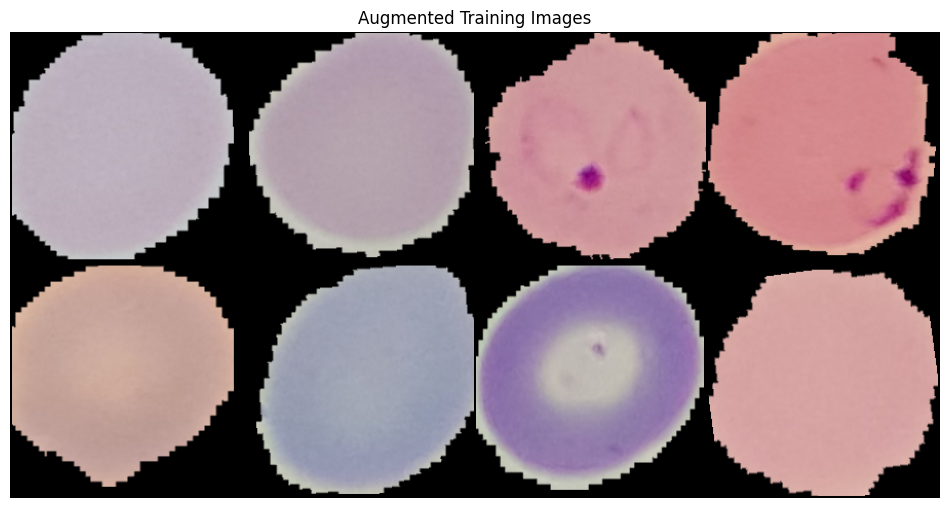

In [24]:
# =====================================================
# STEP 3.7 – VISUALIZE AUGMENTED TRAINING IMAGES
# =====================================================

import matplotlib.pyplot as plt
import torchvision

# Get one batch
images, labels = next(iter(train_loader))

# Undo normalization for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

images = images * std + mean
images = torch.clamp(images, 0, 1)

plt.figure(figsize=(12,8))

grid = torchvision.utils.make_grid(images[:8], nrow=4)

plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Augmented Training Images")

plt.show()